# **PART 2: EXPLORATORY DATA ANALYSIS**


# **I. Import Library**

In [1]:
!pip install pandas
!pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 79.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
import pycountry
import math
from IPython.display import display, HTML

# **II. Import Data**

## 2.1. Import Raw Data from Goolge Drive

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Import CSV into dataframe
df = pd.read_csv('/content/drive/MyDrive/2. Data Projects/1. FDI x Econ Growth/FDI_EconGrowth_Data.csv')

In [5]:
# Display all numeric columns in df to 2 decimals (not changing the original dataset)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [6]:
# Shorten Iran country name
df["country"] = df["country"].replace("Iran, Islamic Republic of", "Iran")

In [7]:
df

,country,iso_alpha3,year,fdi_net_inflow,fdi_net/gdp,elec_access,gov_effect,gcf,trade,gdp_deflat,gdp/cap,school_enroll,labour
0,Bangladesh,BGD,2000,"280,384,629.68",0.53,32.00,-0.61,"1,717,082,946,700.00",29.32,3.45,396.67,5.25,"49,048,139.00"
1,Bangladesh,BGD,2001,"78,527,040.08",0.15,35.00,-0.67,"1,853,328,701,700.00",32.10,3.26,394.66,6.17,"50,230,500.00"
2,Bangladesh,BGD,2002,"52,304,931.04",0.10,37.80,-0.73,"1,990,847,781,400.00",28.97,3.89,393.89,5.92,"51,244,757.00"
3,Bangladesh,BGD,2003,"268,285,231.83",0.45,40.50,-0.84,"2,143,294,043,600.00",27.66,5.82,426.75,5.99,"52,208,969.00"
4,Bangladesh,BGD,2004,"448,905,400.71",0.69,40.60,-0.93,"2,319,228,046,300.00",26.86,4.56,455.61,5.56,"53,140,734.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,Viet Nam,VNM,2019,"16,120,000,000.00",4.82,99.40,0.03,"1,777,370,444,947,100.00",164.70,2.42,"3,440.90",30.22,"56,180,127.00"
308,Viet Nam,VNM,2020,"15,800,000,000.00",4.56,99.80,0.19,"1,850,454,244,961,400.00",163.25,1.47,"3,534.04",36.09,"55,149,609.00"
309,Viet Nam,VNM,2021,"15,660,000,000.00",4.27,100.00,0.24,"1,911,195,913,900,200.00",186.68,2.88,"3,704.19",41.96,"55,299,911.00"
310,Viet Nam,VNM,2022,"17,900,000,000.00",4.33,100.00,0.17,"2,019,204,750,000,000.00",183.15,4.44,"4,147.70",44.75,"56,475,416.00"


## 2.2. Recheck Variables and Countries

In [8]:
# Check country names
df['country'].unique()

array(['Bangladesh', 'Cambodia', 'China', 'India', 'Indonesia', 'Iran',
       'Malaysia', 'Nepal', 'Pakistan', 'Philippines', 'Saudi Arabia',
       'Tajikistan', 'Viet Nam'], dtype=object)

In [9]:
# Check data type and missing value
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         312 non-null    object 
 1   iso_alpha3      312 non-null    object 
 2   year            312 non-null    int64  
 3   fdi_net_inflow  312 non-null    float64
 4   fdi_net/gdp     312 non-null    float64
 5   elec_access     312 non-null    float64
 6   gov_effect      312 non-null    float64
 7   gcf             312 non-null    float64
 8   trade           312 non-null    float64
 9   gdp_deflat      312 non-null    float64
 10  gdp/cap         312 non-null    float64
 11  school_enroll   312 non-null    float64
 12  labour          312 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 31.8+ KB


In [10]:
# Check countries and years
print("Number of countries:", df['country'].nunique())
print("Number of years:", df['year'].nunique())

Number of countries: 13
Number of years: 24


## 2.3 Variable Glossary

In [11]:
# Display full text for the table
pd.set_option('display.max_colwidth', None)

# Create dictionary variable metadata: description + World Bank glossary code
variable_metadata = {
    'fdi_net_inflow': {'description': 'Net FDI inflows (USD)', 'code': 'BX.KLT.DINV.CD.WD'},
    'fdi_net/gdp': {'description': 'Net FDI inflows (% of GDP)','code': 'BX.KLT.DINV.WD.GD.ZS'},
    'elec_access': {'description': 'Shares of population having access to electricity (% of population)', 'code': 'EG.ELC.ACCS.ZS'},
    'gov_effect': {'description': 'Government effectiveness index (range −2.5 to +2.5)', 'code': 'GE.EST'},
    'gcf': {'description': 'Gross capital formation (Constant LCU)', 'code': 'NE.GDI.TOTL.KN'},
    'trade': {'description': 'Trade openness (Sum of Exports and Imports % of GDP)', 'code': 'NE.TRD.GNFS.ZS'},
    'gdp_deflat': {'description': 'GDP deflator (Index number)', 'code': 'NY.GDP.DEFL.ZS'},
    'gdp/cap': {'description': 'GDP per capita (USD)', 'code': 'NY.GDP.PCAP.CD'},
    'school_enroll': {'description': 'School enrollment rate, tertiary level (% gross)', 'code': 'SE.TER.ENRR'},
    'labour': {'description': 'Total labour force (Count)', 'code': 'SL.TLF.TOTL.IN'}}

# Create function to build glossary links
def make_glossary_link(code):
    if code == '':
        return ''
    if code == 'GE.EST':
        return (f'<a href="https://databank.worldbank.org/metadataglossary/'
                f'worldwide-governance-indicators/series/{code}" target="_blank">{code}</a>') # The Goverment index variable has different URL than the rest
    else:
        return (f'<a href="https://databank.worldbank.org/metadataglossary/'
                f'world-development-indicators/series/{code}" target="_blank">{code}</a>')

# Keep only research variables
filtered_vars = [col for col in df.columns if col in variable_metadata]

# Build the variable description table
variables_table = pd.DataFrame({
    'Variable': filtered_vars,
    'Description': [variable_metadata[col]['description'] for col in filtered_vars],
    'World Bank Glossary/ Note': [
        make_glossary_link(variable_metadata[col]['code']) for col in filtered_vars]})

# Display with clickable links
display(HTML(variables_table.to_html(escape=False)))


,Variable,Description,World Bank Glossary/ Note
0,fdi_net_inflow,Net FDI inflows (USD),BX.KLT.DINV.CD.WD
1,fdi_net/gdp,Net FDI inflows (% of GDP),BX.KLT.DINV.WD.GD.ZS
2,elec_access,Shares of population having access to electricity (% of population),EG.ELC.ACCS.ZS
3,gov_effect,Government effectiveness index (range −2.5 to +2.5),GE.EST
4,gcf,Gross capital formation (Constant LCU),NE.GDI.TOTL.KN
5,trade,Trade openness (Sum of Exports and Imports % of GDP),NE.TRD.GNFS.ZS
6,gdp_deflat,GDP deflator (Index number),NY.GDP.DEFL.ZS
7,gdp/cap,GDP per capita (USD),NY.GDP.PCAP.CD
8,school_enroll,"School enrollment rate, tertiary level (% gross)",SE.TER.ENRR
9,labour,Total labour force (Count),SL.TLF.TOTL.IN


Above is the Glossary Description table for the reader's reference on the variables

# **III. Exploratory Data Analysis**

## 3.1. FDI Inflow Trend

In [12]:
# Create animated choropleth map
fig = px.choropleth(
    df,
    locations="iso_alpha3",
    color="fdi_net/gdp",
    animation_frame="year",
    projection="natural earth",
    color_continuous_scale=px.colors.diverging.RdBu_r,
    range_color=(-12, 12),
    labels={"fdi_net/gdp": "FDI / GDP (%)"},
    title="<b>Map Net FDI Inflow of GDP (2000-2023)<b>")

# Mark country name on the map
fig.add_trace(
    px.scatter_geo(
        df,
        locations="iso_alpha3",
        text="country",
        projection="natural earth"
    ).data[0])

fig.update_traces(
    textfont=dict(size=10, color="black"),
    textposition="top center",
    selector=dict(type="scattergeo"))

# Add according year above the map
for frame in fig.frames:
    year = frame.name  # animation_frame value

    frame.layout = dict(
        annotations=[
            dict(
                text=f"{year}",
                x=0.5,           # center horizontally
                y=1.08,          # above the mapd
                xref="paper",
                yref="paper",
                showarrow=False,
                font=dict(size=18, color="black"),
                bgcolor="rgba(255,255,255,0.85)",
                bordercolor="black",
                borderwidth=1)])

# Display map
fig.update_layout(
    width=1200,
    height=700)

fig.show()


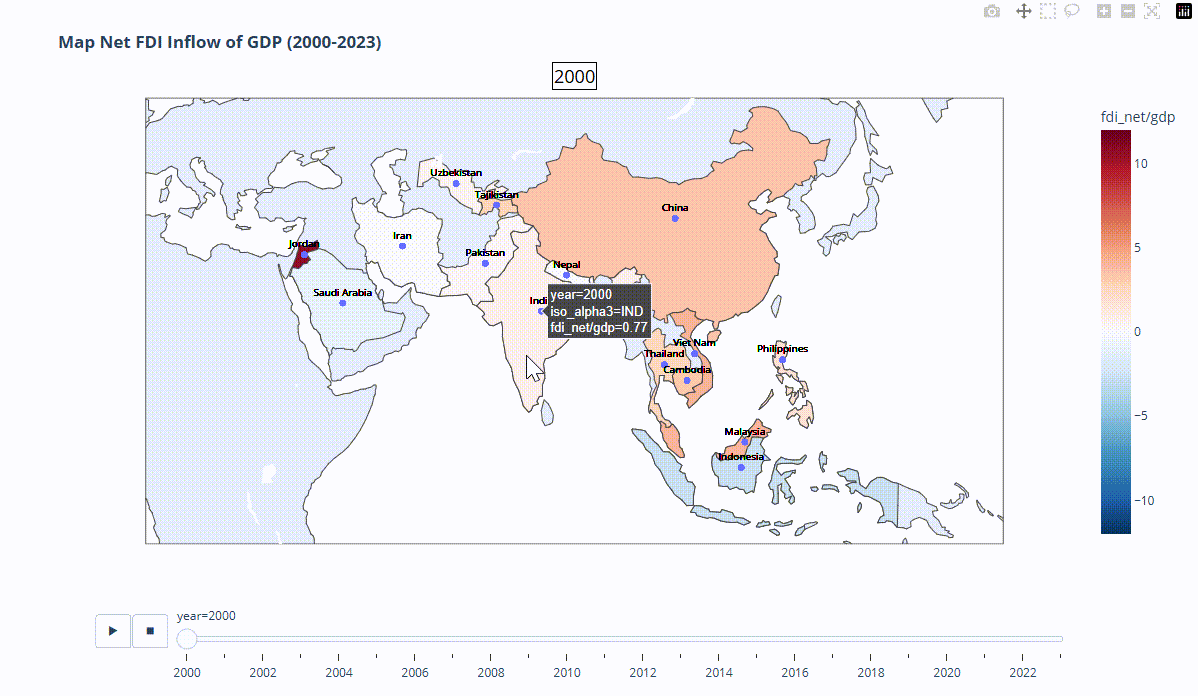

**West Asia:**

- **Iran**’s persistently low values (Avg 0.77%) are consistent with political risk and restricted capital mobility, limiting sustained foreign investment ([Rafat and Farahani's study, 2019](https://ier.ut.ac.ir/article_69107_b689d1fd0cdd4fe3f492bdb33e7b3db2.pdf?utm_source=chatgpt.com)).

- **Saudi Arabia**’s low FDI/GDP (Avg 0.81%) suggests that growth is driven primarily by oil revenues and domestic capital, making FDI relatively less important as a share of GDP ([Mahmood and Alkhateeb's study, 2018](https://www.researchgate.net/publication/327732262_Foreign_Direct_Investment_Domestic_Investment_and_Oil_Price_Nexus_in_Saudi_Arabia))

**Central Asia:**

- **Tajikistan**’s spikes in the late 2000s (Avg ~9%, 2004-2008) reflects in the large, project-based investments such as hydropower and mining ([World Bank's report, 2007](https://documents1.worldbank.org/curated/en/437331468341061852/pdf/39958.pdf)). Its small GDP base (Avg 3.2 billion USD, 2004-2008) also should be considered for this high ratio.

**South Asia:**

- **Bangladesh** (Avg 0.8%), **Nepal** (Avg 0.2%), and **Pakistan** (Avg 0.9%) maintain consistently low FDI/GDP, with minimal volatility.

- **India** shows a steady but modest increase in FDI/GDP throughout the years (1% – 3%). Asessing its large-scale GDP, it could be indicated that India economic growth has not been heavily dependent on FDI.

**East Asia:**

- **Malaysia** (Avg 3%) and **Philippines** (Avg 1.7%) exhibit medium and relatively stable levels due to its stable politics and affairs.

- **Indonesia** shows negative figures in the early 2000s (Avg -1.2%, 2000-2003), influenced by the Asian Financial Crisis and the unstable politic affair (Fall of Suharto
 in 1998). After the period, Indonesia started to gradually attract FDI (Avg 1.8%, 2004-2023)

- **China** shows moderate and stable FDI/GDP ratio until 2013 (Avg 3.6%, 2000-2013). This aligns well with WTO accesion in 2001 and its encouraging policy on FDI attraction and exporting strategies. The FDI mostly flew into electronics, apparel, and assembly manufacturing, mostly set in Special Economic Zones ([Zeng's study, 2012](https://www.lincolninst.edu/app/uploads/legacy-files/pubfiles/2261_1600_Zeng_WP13DZ1.pdf)). After 2013, China gradually relied less on inward FDi and became a major outward investors ([UNCTAD, 2022](https://unctad.org/publication/world-investment-report-2022)). The denominator (GDP growth) effect also should be considered in this period as its GDP had grown enormously in the 2010s.

- **Cambodia** stands out as one of the countries with the highest FDI/ GDP ratios in the sample (Avg 7.6%). China is a major source of its FDI, accounting for nearly 50 percent of Cambodia’s total FDI inflows. In addition, Cambodia has established SEZs, modeled in part on China’s experience, to further attract FDI ([Asean Business Partners's article](https://bizasean.com/foreign-direct-investment-cambodia)).

- **Vietnam** is also in the top countries for the most stable FDI/GDP (Avg 4.8%). Vietnam's ability to attract consistent FDI is largely due to its stable socio-political environment and consistent pro-investment government policies that foster high investor confidence. Additionally, active participation in numerous free trade agreements like the CPTPP and RCEP has embedded the nation into global production networks. Notably, during 2007-2009, Vietnam saw the highest ratio (Avg 8.5%, 2007-2009), following its accession to the World Trade Organization in January 2007, which boosted investor confidence and market access. ([NUS's research](https://research.nus.edu.sg/eai/wp-content/uploads/2017/11/Vol1No2_LeThiThuy.pdf)).

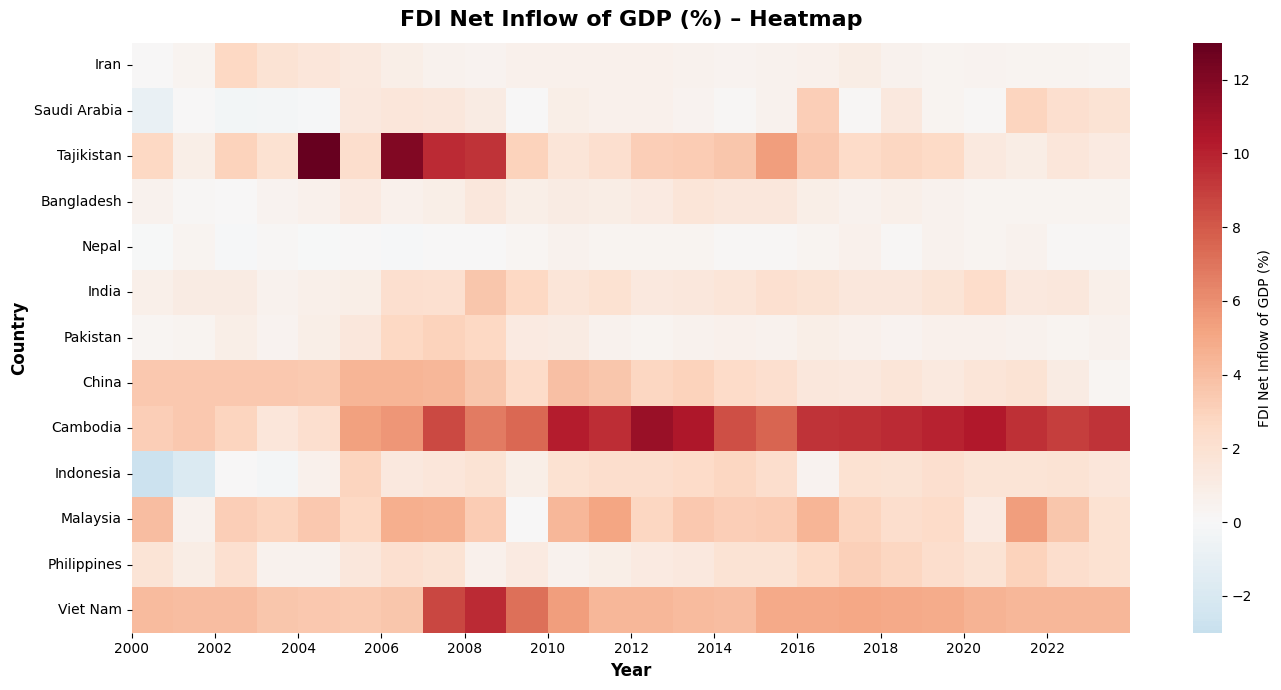

In [13]:
# Pivot (country becomes the index automatically)
hm_matrix = df.pivot_table(
    index="country",
    columns="year",
    values="fdi_net/gdp",
    aggfunc="mean")

# Desired country order
country_order = ["Iran", "Saudi Arabia", "Tajikistan", "Bangladesh", "Nepal", "India", "Pakistan", "China", "Cambodia", "Indonesia", "Malaysia", "Philippines", "Viet Nam"]

# Reorder rows
hm_matrix = hm_matrix.reindex(country_order)

# Plot
plt.figure(figsize=(14, 7))

ax = sns.heatmap(
    hm_matrix,
    cmap="RdBu_r",
    vmin=-3,
    vmax=13,
    center=0,
    cbar_kws={"label": "FDI Net Inflow of GDP (%)"})

# X-axis: show every 2 years
years = hm_matrix.columns.tolist()
ax.set_xticks(range(0, len(years), 2))
ax.set_xticklabels(years[::2])

# Labels and title (bold)
ax.set_xlabel("Year", fontsize=12, fontweight="bold")
ax.set_ylabel("Country", fontsize=12, fontweight="bold")
ax.set_title("FDI Net Inflow of GDP (%) – Heatmap",
             fontsize=16, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()


Above is the FDI Net Inflow/ GDP heatmap on a flat scale for the readers to clearly see the fluctuation across countries.

## 3.2. GDP Trend

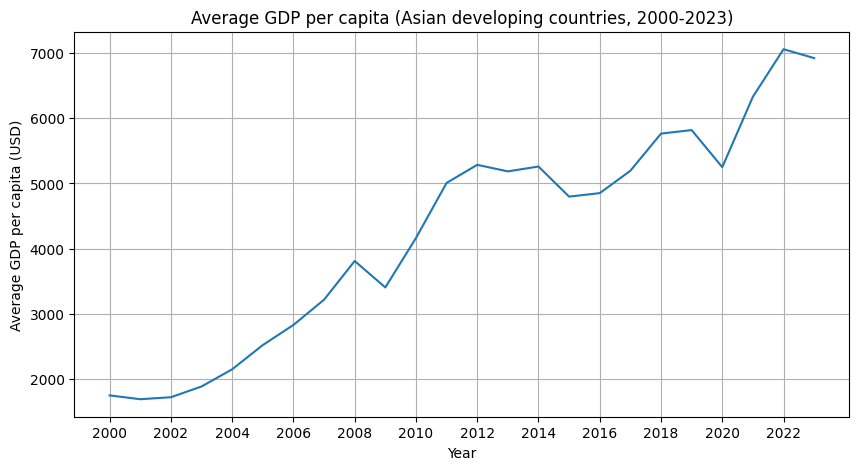

In [14]:
# Compute average GDP per capita by year
avg_gdp_time = df.groupby('year')['gdp/cap'].mean()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(avg_gdp_time.index, avg_gdp_time.values)
plt.xlabel('Year')
plt.ylabel('Average GDP per capita (USD)')
plt.title('Average GDP per capita (Asian developing countries, 2000-2023)')
plt.grid(True)

# Set x-axis ticks every 2 years
years = avg_gdp_time.index.values
plt.xticks(years[::2])

plt.show()


The figure illustrates the evolution of average GDP per capita across Asian developing countries over the period 2000–2023.

Overall, income levels rise steadily over time, even though there are temporary slowdowns around major global events such as the 2008–2009 financial crisis and the COVID-19 pandemic in 2020. The clear upward pattern highlights strong time variation in the data, which supports using the panel structure to analyze how economic growth evolves across countries over time.

## 3.3. Bivariate Analysis

### 3.3.1. Descriptive Summary

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,312.00,"2,011.50",6.93,"2,000.00","2,005.75","2,011.50","2,017.25","2,023.00"
fdi_net_inflow,312.00,"19,293,806,431.73","51,370,820,603.83","-4,550,355,285.71","548,960,526.32","2,747,749,659.23","10,025,559,717.70","344,074,977,062.48"
fdi_net/gdp,312.00,2.34,2.52,-2.76,0.61,1.62,3.17,13.10
elec_access,312.00,86.20,20.62,9.50,82.00,96.15,99.50,100.00
gov_effect,312.00,-0.28,0.58,-1.24,-0.76,-0.33,0.06,1.24
gcf,312.00,"2,470,806,060,222,150.50","8,334,438,792,754,000.00","-8,634,936,571,451,501.00","597,282,979,805.19","4,897,317,985,700.00","45,245,660,658,950.00","41,779,052,123,930,600.00"
trade,312.00,73.52,45.23,21.46,41.91,54.72,110.10,220.41
gdp_deflat,312.00,7.92,9.44,-16.56,3.19,5.62,9.53,68.01
gdp/cap,312.00,"4,245.32","6,361.88",136.93,876.88,"1,794.36","4,209.82","38,510.23"
school_enroll,312.00,25.38,16.54,1.87,12.83,23.46,32.96,77.97


The table above presents descriptive statistics for the variables used in the analysis, based on 384 observations for Asian developing countries over the period 2000–2023.

- **High-dispersion variables:**

FDI net inflow, GDP per cap, Labour show a wide spreaded distribution, with standard deviations significantly larger than their means.

- **Moderate-variation variables:**

FDi net inflow of GDP, Trade openess, Access to electricity, Government effectiveness, School enrollment tertiary, GDP deflator, Gross capital formation show contained variation as they are ratio-based or index variables with their lower standard deviations compared to means.




The dispersion problems can be solved by a methods called [Logarithmic Transformations](https://www.sciencedirect.com/topics/mathematics/logarithmic-transformation)

- FDI net inflows, GDP per capita, labour force, gross capital formation (based on Solow Growth model) are transformed into logarithmic form to limit the influence of extreme observations and to enable consistent interpretation within the framework.
- FDI/GDP, trade openness, access to electricity, government effectiveness, and school enrollment (ratio and index variables) are retained in their original values, as log transformation would be either mathematically invalid or misleading. Interaction terms are also kept in levels to ensure clear interpretation of conditional FDI effects in regression analysis.

### 3.3.2. Histograms

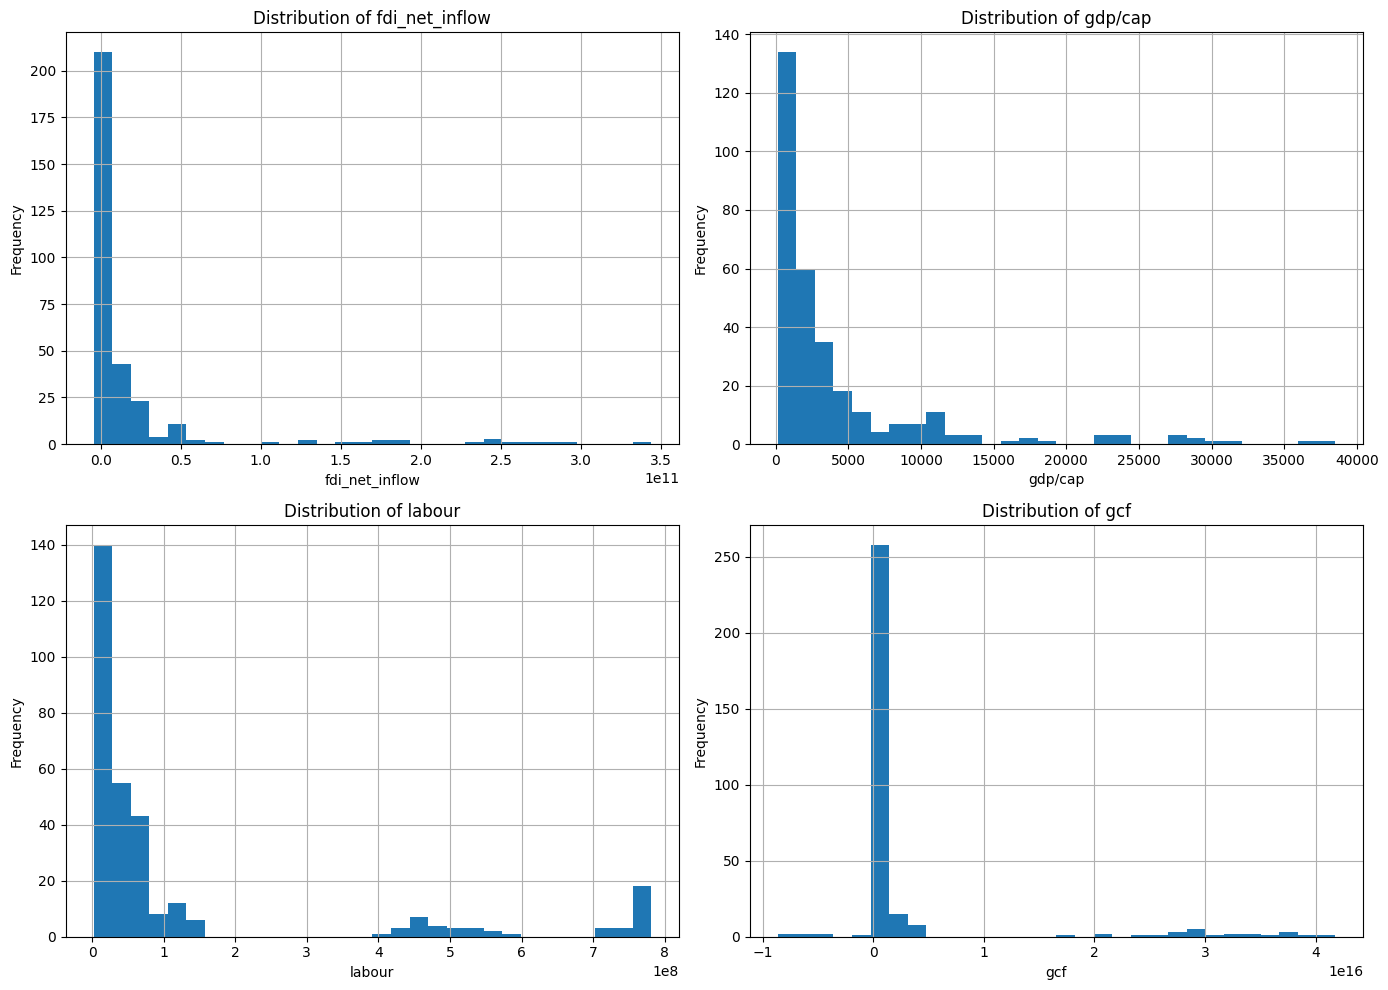

In [16]:
# List of high dispersion variables
high_dispersion_variables = ['fdi_net_inflow', 'gdp/cap', 'labour', 'gcf']

# Set number of columns
cols = 2
rows = math.ceil(len(high_dispersion_variables) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()  # Flatten in case of multiple rows

for i, var in enumerate(high_dispersion_variables):
    axes[i].hist(df[var], bins=30)
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True)

# Remove empty subplot if number of variables is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


- The histograms shows significant right-skewness for the four variables with observations concentrated at lower values and a long right tail reflecting scale effect. These distributions justify the use of logarithmic transformations to stabilize variance and reduce the influence of extreme outliers.

- Gross Capital Formation (GCF) can occasionally take negative values when measured in real terms because it reflects net investment in the economy. While gross investment is typically positive, adjustments in national accounts, such as large inventory reductions, revaluation effects, or statistical revisions, can lead to negative recorded values in some years. This does not necessarily mean that physical capital becomes negative, but rather that total investment activity during that period was very weak or offset by disinvestment components.

### 3.3.3. Scatter Plots

In this part, I will discover how bivariate relationship differs when the variables are logged and when they aren't

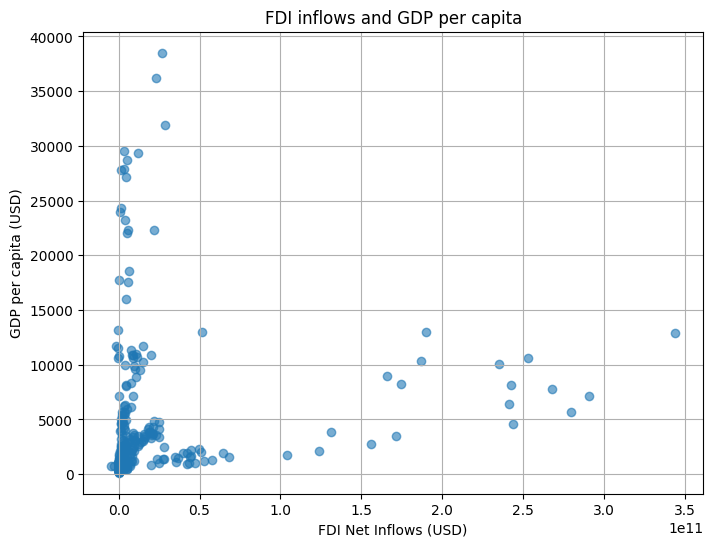

In [17]:
# Plot FDI net inflow and GDP per cap

plt.figure(figsize=(8, 6))
plt.scatter(df['fdi_net_inflow'], df['gdp/cap'], alpha=0.6)

plt.xlabel('FDI Net Inflows (USD)')
plt.ylabel('GDP per capita (USD)')
plt.title('FDI inflows and GDP per capita')

plt.grid(True)
plt.show()


- The scatter plot of FDI net inflows and GDP per capita shows significant clustering at low FDI values, with a moderate number of extreme observations stretching the scale. The plot shows no clear linear pattern suggests that absolute FDI inflows are heavily influenced by country size and scale effects.

- This supports the use of logarithmic transformation to better capture proportional relationships and reduce the influence of outliers in regression analysis.

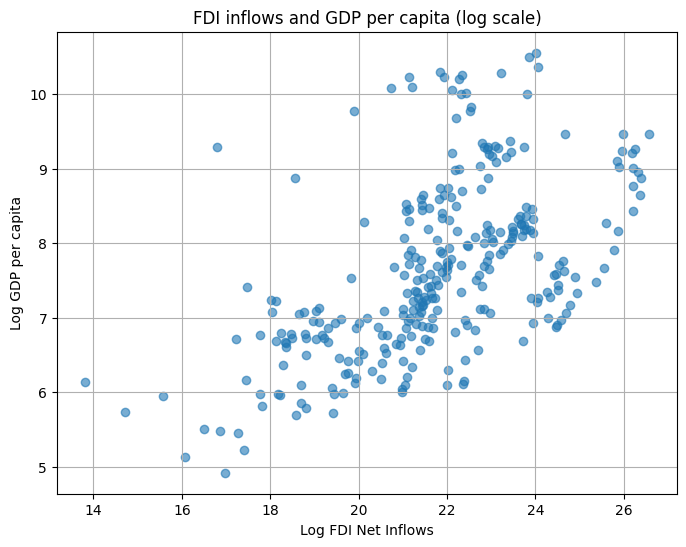

In [18]:
# Create a copy
df_plot = df.copy()

# Keep only positive FDI inflows
df_plot = df_plot[df_plot['fdi_net_inflow'] > 0].copy()

# Create log variables
df_plot['ln_fdi'] = np.log(df_plot['fdi_net_inflow'])
df_plot['ln_gdp_cap'] = np.log(df_plot['gdp/cap'])

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(df_plot['ln_fdi'], df_plot['ln_gdp_cap'], alpha=0.6)

plt.xlabel('Log FDI Net Inflows')
plt.ylabel('Log GDP per capita')
plt.title('FDI inflows and GDP per capita (log scale)')
plt.grid(True)

plt.show()

In the log scale, the relationship between FDI inflow and GDP per cap is much clearer, supporting the use of relative and logarithmic measures in panel regressions. Unlike the level plot, the observations are no longer heavily concentrated around zero. The data points are more evenly spread across the graph, making the overall pattern easier to see. The plot shows a relative postive correlation between the two logged variables. While the relationship is not perfectly linear and some dispersion remains, the overall trend is clearly upward.

### 3.3.4. Correlation Matrix

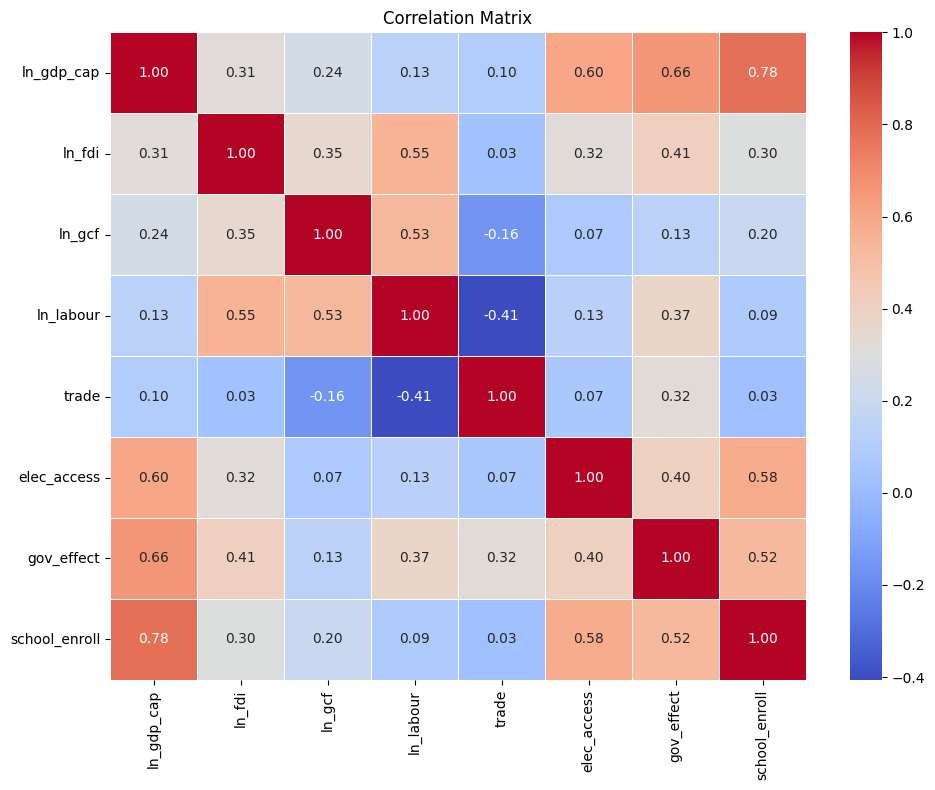

In [21]:
# Copy data to avoid modifying original dataframe
df_corr = df.copy()

# Remove observations with non-positive GCF (required for log transformation)
df_corr = df_corr[df_corr['gcf'] > 0]

# Log-transform scale-heavy variables
df_corr['ln_gdp_cap'] = np.log(df_corr['gdp/cap'])
df_corr['ln_fdi'] = np.log(df_corr['fdi_net_inflow'].clip(lower=1)) # Clip lower bound at 1 to avoid log of zero or negative values
df_corr['ln_gcf'] = np.log(df_corr['gcf'])
df_corr['ln_labour'] = np.log(df_corr['labour'])

# Select all analysis variables (exclude identifiers)
corr_vars = [
    'ln_gdp_cap',
    'ln_fdi',
    'ln_gcf',
    'ln_labour',
    'trade',
    'elec_access',
    'gov_effect',
    'school_enroll']

# Compute correlation matrix
corr_matrix = df_corr[corr_vars].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

The correlation matrix presents the relationships between each pair of variables included in the analysis. The observed patterns are in line with the regression specification, providing initial support for the structure of the empirical model.

- Log GDP per capita has a moderate positive correlation with log FDI (0.31) => Support the hypothesis that higher FDI inflows are generally associated with higher GDP.
- Stronger positive correlations are also seen between GDP per capita and institutional or development indicators, such as electricity access (0.60), government effectiveness (0.66), school enrollment (0.78) => Justify the inclusion of these control variables in the model, as they appear closely linked to economic performance.

Overall, the matrix does not indicate severe multicollinearity among the main regressors. The regression analysis will formally test these relationships in the next part, using within-country variation over time.